# Introduction

Stroke is the third leading cause of death, globally, according to [WHO 2021 data](https://www.who.int/news-room/fact-sheets/detail/the-top-10-causes-of-death), after Ischaemic Heart Disease and COVID-19, accounting for roughly 10% of total global deaths, and the rate has been increasing in the 2000-2019 and 2019-2021 periods.

This burden goes well beyond the death counts as stroke leads to major long term disability in survivors and places a heavy ongoing demand on healthcare systems everywhere with many patients needing extended rehabilitation and daily support that drives up costs fast in both personal hardship and economic terms.

Prediction modeling has therefore become a key focus area in recent years since spotting individuals at higher risk ahead of time can change some of those trajectories especially as targeted prevention steps, like blood pressure control or habit adjustments work much better when applied to the right people. In this repository the goal is to try to establish predictive models via machine learning algorithms, using Stroke Prediction Dataset to uncover connections between features in this dataset with stroke occurrence.

# Exploratory Data Analysis

In [44]:
import warnings
warnings.filterwarnings('ignore')

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
import os

df = pd.read_csv(os.path.join('..', 'data', 'stroke-prediction-dataset.csv'))
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1084,35866,Female,62.0,0,0,Yes,Private,Rural,91.65,30.5,never smoked,0
2746,35315,Male,65.0,0,0,Yes,Self-employed,Urban,95.88,28.5,never smoked,0
3177,22964,Male,44.0,0,0,Yes,Govt_job,Rural,69.23,28.7,smokes,0
1305,17639,Male,44.0,0,0,Yes,Govt_job,Rural,87.49,26.6,never smoked,0
1666,44010,Female,3.0,0,0,No,children,Urban,57.33,16.8,Unknown,0


### Data Overview & Initial Cleaning

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [48]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


In [49]:
categorical_features = [
    'Residence_type', 'gender', 'hypertension', 'heart_disease', 'ever_married',
    'work_type', 'smoking_status'
]
for cf in categorical_features:
    print(f"{cf}: {df[cf].unique()}")

Residence_type: ['Urban' 'Rural']
gender: ['Male' 'Female' 'Other']
hypertension: [0 1]
heart_disease: [1 0]
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


There are no sentinel or unexpected values than those listed in the dataset about file.

In [50]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

There is remarkable class imbalance in target variable and this will be potentially problematic for positive case (stroke+) predictions.

In [51]:
for col in df.columns:
    print(f'{col}: {df[col].isna().sum()} / {len(df)}')

id: 0 / 5110
gender: 0 / 5110
age: 0 / 5110
hypertension: 0 / 5110
heart_disease: 0 / 5110
ever_married: 0 / 5110
work_type: 0 / 5110
Residence_type: 0 / 5110
avg_glucose_level: 0 / 5110
bmi: 201 / 5110
smoking_status: 0 / 5110
stroke: 0 / 5110


Only bmi has missing values and there are 201/5110 incomplete rows. The most conservative approach is to discard rows that have missing data; i.e. Complete Case Analysis.

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
data = df[categorical_features + numeric_features + ['stroke']]
data = data.dropna()
data.sample(5)

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke
228,Urban,Female,0,0,Yes,Self-employed,smokes,39.0,97.76,29.6,1
4766,Rural,Male,0,0,No,Govt_job,never smoked,16.0,78.48,22.6,0
1959,Urban,Male,0,0,No,children,Unknown,3.0,82.73,20.8,0
2347,Rural,Male,0,0,No,children,Unknown,6.0,64.55,17.4,0
1253,Urban,Male,0,0,No,children,Unknown,11.0,92.17,19.5,0


In [54]:
data.shape, data.isna().sum()

((4909, 11),
 Residence_type       0
 gender               0
 hypertension         0
 heart_disease        0
 ever_married         0
 work_type            0
 smoking_status       0
 age                  0
 avg_glucose_level    0
 bmi                  0
 stroke               0
 dtype: int64)

### Univariate Distributions

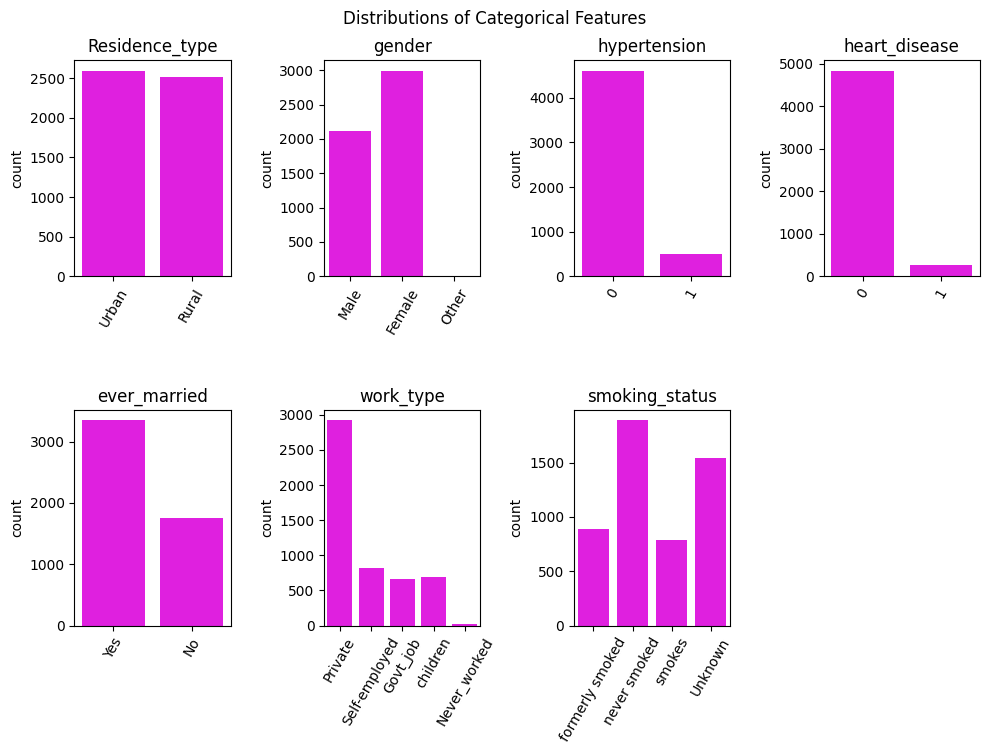

In [55]:
fig, axes = plt.subplots(ncols=4, nrows=3, figsize=(10, 10))

axes = axes.flatten()
for col, ax in zip(categorical_features, axes):
    sns.countplot(data=df, x=col, ax=ax, color='magenta')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=60)

for i in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Distributions of Categorical Features")
plt.tight_layout()

                Residence_type      Ratio
Residence_type                           
Urban                     2490  50.723162
Rural                     2419  49.276838


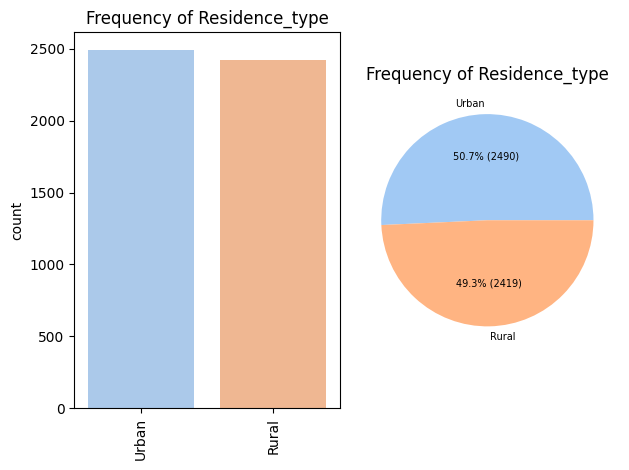

        gender      Ratio
gender                   
Female    2897  59.014056
Male      2011  40.965573
Other        1   0.020371


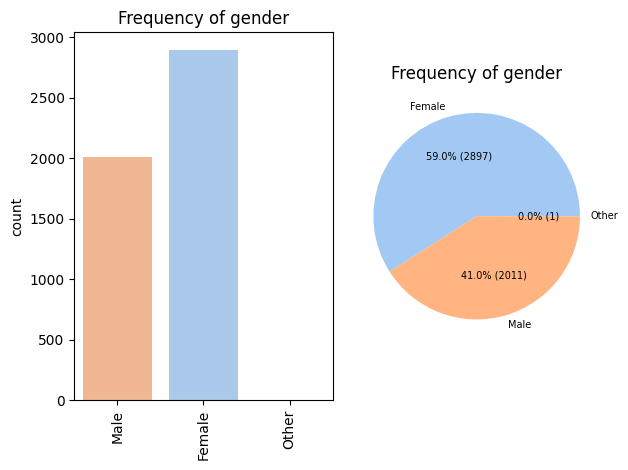

              hypertension      Ratio
hypertension                         
0                     4458  90.812793
1                      451   9.187207


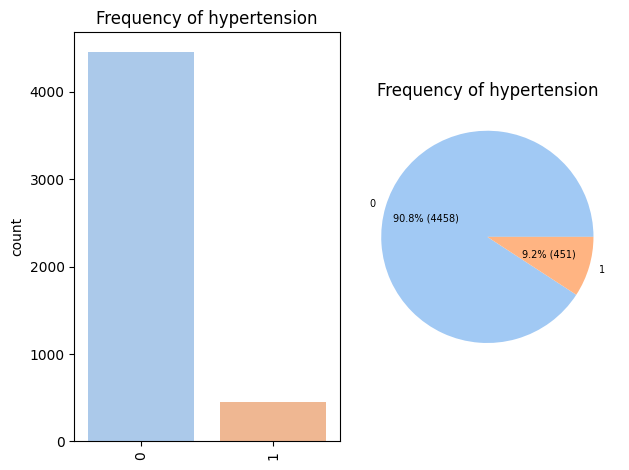

               heart_disease      Ratio
heart_disease                          
0                       4666  95.049908
1                        243   4.950092


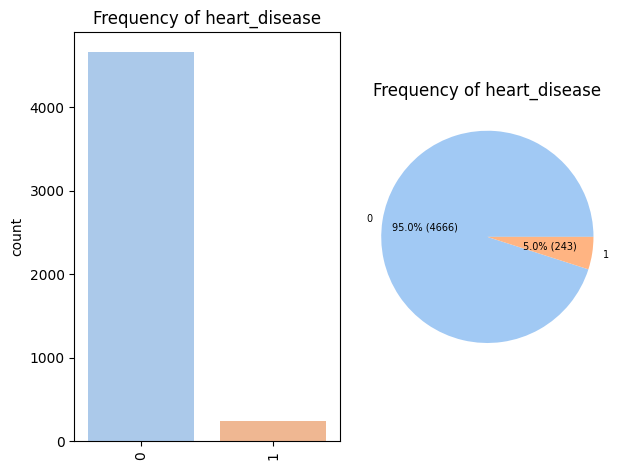

              ever_married      Ratio
ever_married                         
Yes                   3204  65.267875
No                    1705  34.732125


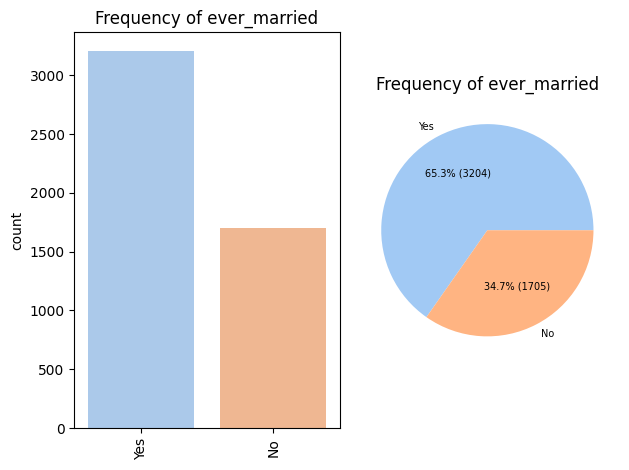

               work_type      Ratio
work_type                          
Private             2811  57.262172
Self-employed        775  15.787329
children             671  13.668772
Govt_job             630  12.833571
Never_worked          22   0.448156


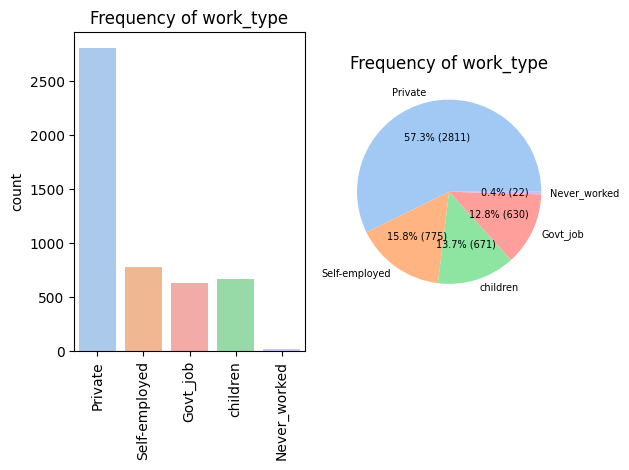

                 smoking_status      Ratio
smoking_status                            
never smoked               1852  37.726625
Unknown                    1483  30.209819
formerly smoked             837  17.050316
smokes                      737  15.013241


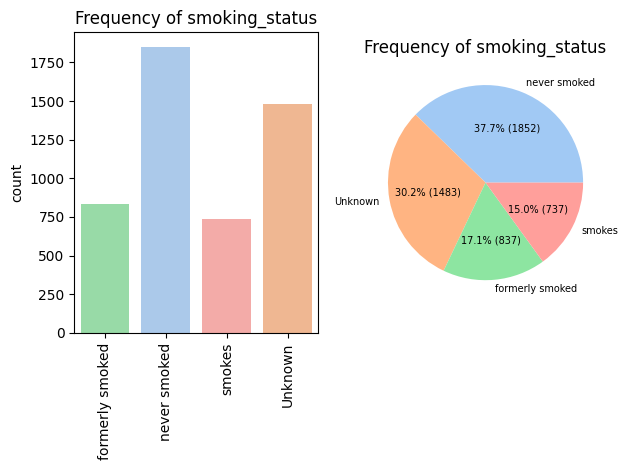

In [56]:
def cat_summary(data, col_name):
    counts = data[col_name].value_counts()
    ratio = 100 * counts / len(data)
    summary = pd.DataFrame({col_name: counts, "Ratio": ratio})
    print(summary)

    categories = counts.index.astype(str)
    palette = dict(zip(categories, sns.color_palette("pastel", len(categories))))

    plt.subplot(1, 2, 1)
    sns.countplot(x=col_name, data=data, palette=palette)
    plt.title("Frequency of " + col_name)
    plt.xticks(rotation=90)
    plt.xlabel('')

    plt.subplot(1, 2, 2)
    values = counts
    plt.pie(
        x=values,
        labels=values.index.astype(str),
        autopct=lambda p: '{:.1f}% ({:.0f})'.format(p, p / 100 * sum(values)),
        colors=[palette[str(cat)] for cat in values.index],
        textprops={'fontsize': 7}
    )
    plt.title("Frequency of " + col_name)

    plt.tight_layout()
    plt.show()

for col in categorical_features:
    cat_summary(data, col)

The dataset is predominantly Female (comprises about 60% of the cases), but the notable thing is there is only 1 case for `Other` gender so we should obviously remove it from the dataset.

The rest of the features are clinically justified.

In [57]:
data = data[data['gender'] != 'Other']
data

,Residence_type,gender,hypertension,heart_disease,ever_married,work_type,smoking_status,age,avg_glucose_level,bmi,stroke
0,Urban,Male,0,1,Yes,Private,formerly smoked,67.0,228.69,36.6,1
2,Rural,Male,0,1,Yes,Private,never smoked,80.0,105.92,32.5,1
3,Urban,Female,0,0,Yes,Private,smokes,49.0,171.23,34.4,1
4,Rural,Female,1,0,Yes,Self-employed,never smoked,79.0,174.12,24.0,1
5,Urban,Male,0,0,Yes,Private,formerly smoked,81.0,186.21,29.0,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Rural,Female,0,0,No,children,Unknown,13.0,103.08,18.6,0
5106,Urban,Female,0,0,Yes,Self-employed,never smoked,81.0,125.20,40.0,0
5107,Rural,Female,0,0,Yes,Self-employed,never smoked,35.0,82.99,30.6,0
5108,Rural,Male,0,0,Yes,Private,formerly smoked,51.0,166.29,25.6,0


count    4908.000000
mean       42.868810
std        22.556128
min         0.080000
5%          4.000000
10%        10.000000
20%        20.000000
30%        29.000000
40%        37.000000
50%        44.000000
60%        51.000000
70%        57.000000
80%        64.000000
90%        74.000000
95%        79.000000
99%        82.000000
max        82.000000
Name: age, dtype: float64


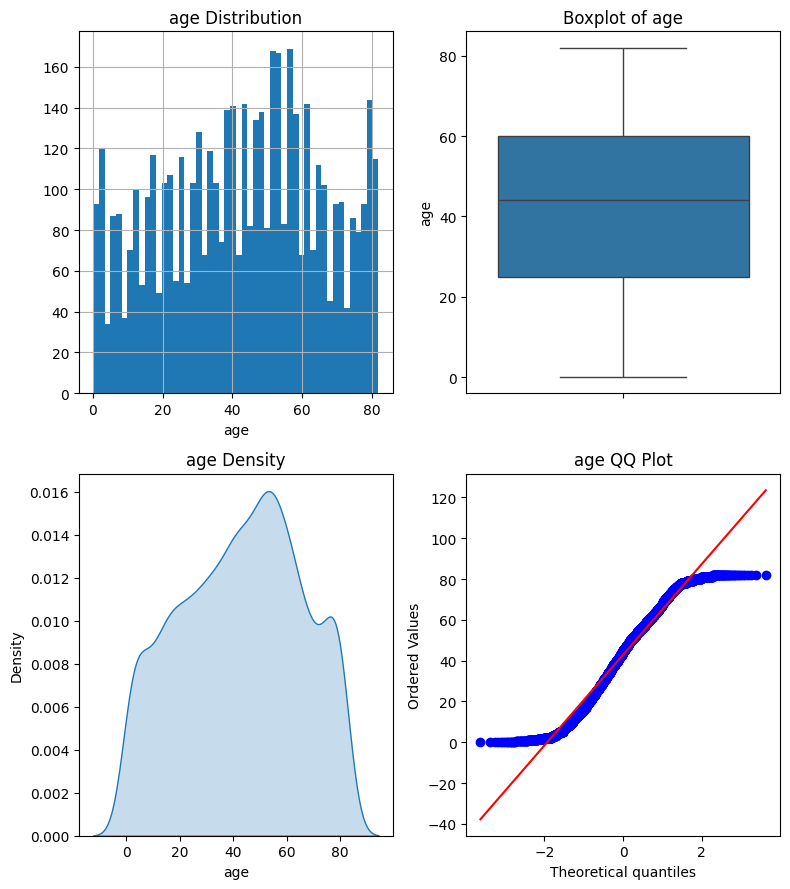

########################################
count    4908.000000
mean      105.297402
std        44.425550
min        55.120000
5%         60.610000
10%        65.624000
20%        73.664000
30%        79.890000
40%        85.444000
50%        91.680000
60%        98.522000
70%       108.026000
80%       123.100000
90%       187.031000
95%       214.653000
99%       240.555000
max       271.740000
Name: avg_glucose_level, dtype: float64


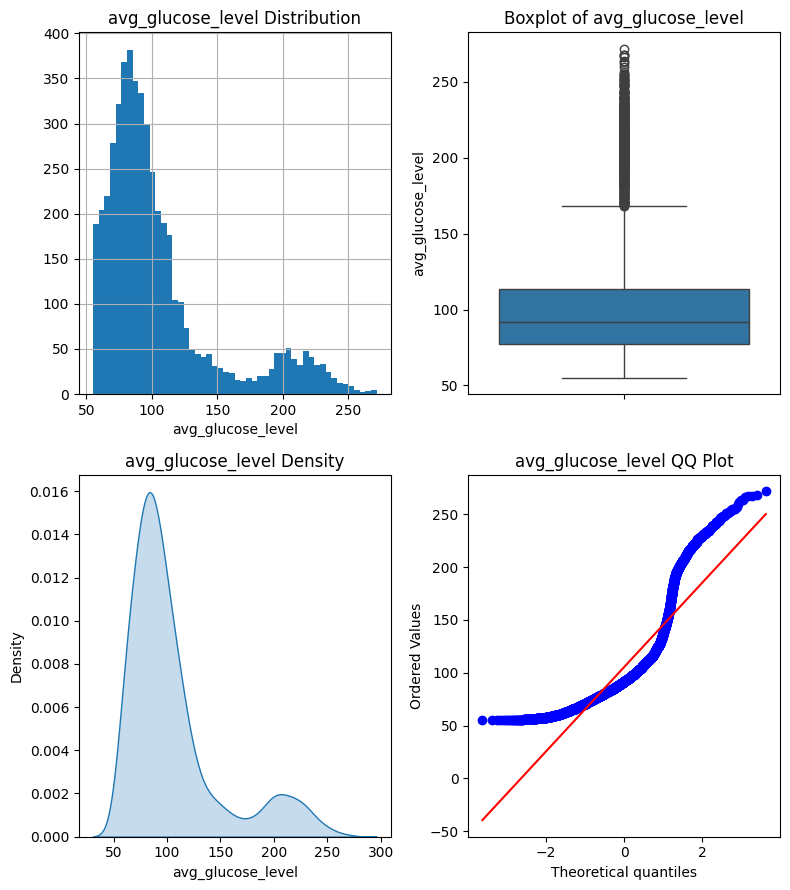

########################################
count    4908.00000
mean       28.89456
std         7.85432
min        10.30000
5%         17.63500
10%        19.70000
20%        22.50000
30%        24.50000
40%        26.40000
50%        28.10000
60%        29.80000
70%        31.90000
80%        34.50000
90%        38.90000
95%        42.96500
99%        53.40000
max        97.60000
Name: bmi, dtype: float64


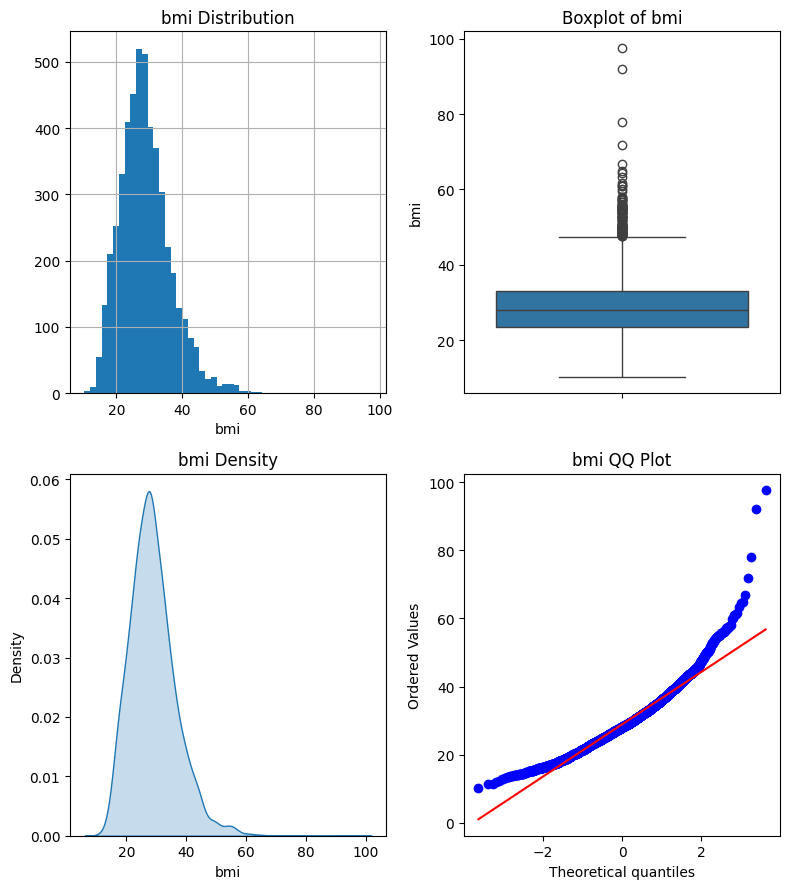

########################################


In [58]:
import scipy.stats as stats

def num_summary(data, numerical_col):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(data[numerical_col].describe(quantiles).T)

    plt.figure(figsize=(8, 9))
    plt.subplot(2, 2, 1)
    data[numerical_col].hist(bins=50)
    plt.xlabel(numerical_col)
    plt.title(numerical_col + " Distribution")

    plt.subplot(2, 2, 2)
    sns.boxplot(y=numerical_col, data=data)
    plt.title("Boxplot of " + numerical_col)

    plt.subplot(2, 2, 3)
    sns.kdeplot(data[numerical_col], shade=True)
    plt.xlabel(numerical_col)
    plt.title(numerical_col + " Density")

    plt.subplot(2, 2, 4)
    stats.probplot(data[numerical_col], dist="norm", plot=plt)
    plt.title(numerical_col + " QQ Plot")

    plt.tight_layout()
    plt.show()

    print("#" * 40)

for col in numeric_features:
    num_summary(data, col)

Age distribution is unimodal, centered in the mid‑50s, spanning from infancy to about 82. The histogram shows spikiness due to integer recording and clustering around 40–60. The QQ plot indicates near‑normality in the middle but lighter tails: low ages aren’t as extreme as a normal would predict, and high ages flatten below the theoretical line since age is naturally bounded at 0 and capped near 82. Overall, deviations are mild and expected given age’s natural limits.

BMI shows extreme outliers in the upside (top 1% scattered through 53 to 97).

Glucose shows a bimodal distribution but the overall values are not outside the clinically expected range.

Remove bmi outliers

In [59]:
q1 = data["bmi"].quantile(0.25)
q3 = data["bmi"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(lower_bound, upper_bound)

data_clean = data[(data["bmi"] >= lower_bound) & (data["bmi"] <= upper_bound)]

print(data.shape, data_clean.shape)
data_clean["bmi"].describe()

9.099999999999998 47.5
(4908, 11) (4798, 11)


count    4798.000000
mean       28.314819
std         6.841431
min        10.300000
25%        23.425000
50%        27.900000
75%        32.600000
max        47.500000
Name: bmi, dtype: float64

count    4798.000000
mean       42.832247
std        22.724885
min         0.080000
5%          4.000000
10%        10.000000
20%        20.000000
30%        29.000000
40%        37.000000
50%        44.000000
60%        51.000000
70%        57.000000
80%        64.000000
90%        74.000000
95%        79.000000
99%        82.000000
max        82.000000
Name: age, dtype: float64


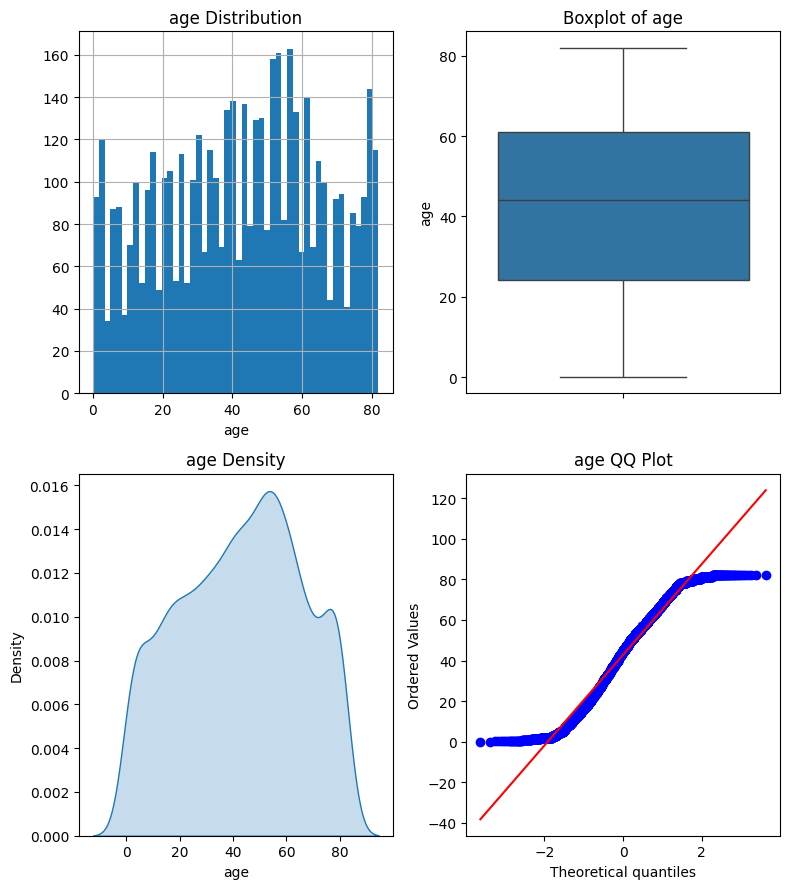

########################################
count    4798.000000
mean      104.960961
std        44.040560
min        55.120000
5%         60.610000
10%        65.587000
20%        73.654000
30%        79.872000
40%        85.330000
50%        91.650000
60%        98.394000
70%       107.830000
80%       122.472000
90%       183.984000
95%       213.877500
99%       240.713000
max       271.740000
Name: avg_glucose_level, dtype: float64


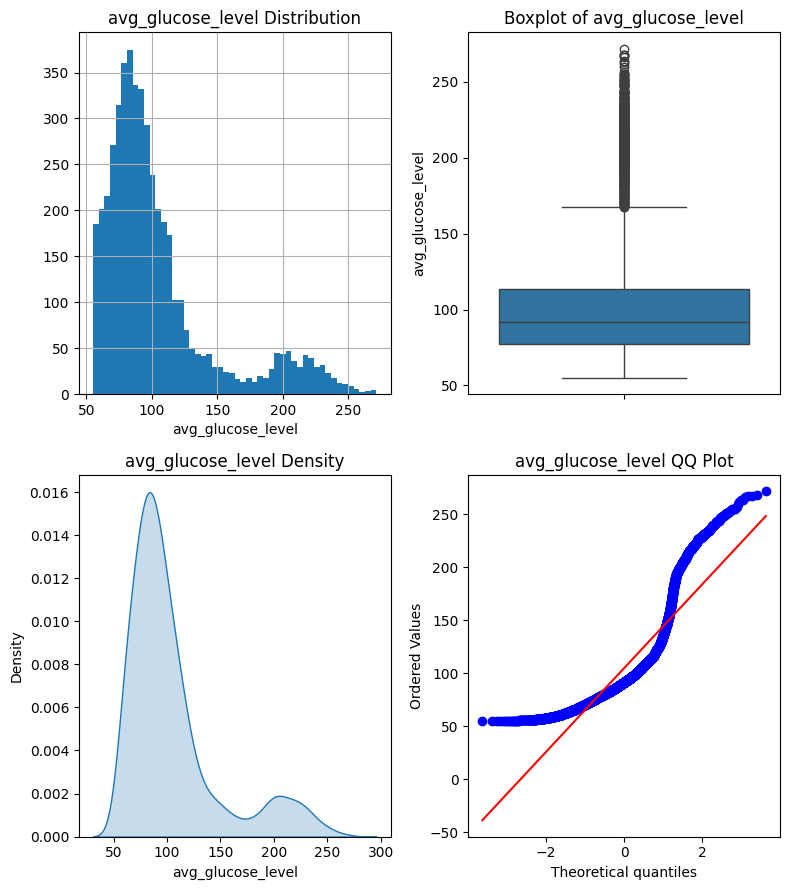

########################################
count    4798.000000
mean       28.314819
std         6.841431
min        10.300000
5%         17.600000
10%        19.600000
20%        22.400000
30%        24.400000
40%        26.300000
50%        27.900000
60%        29.500000
70%        31.500000
80%        34.000000
90%        37.800000
95%        40.900000
99%        45.000000
max        47.500000
Name: bmi, dtype: float64


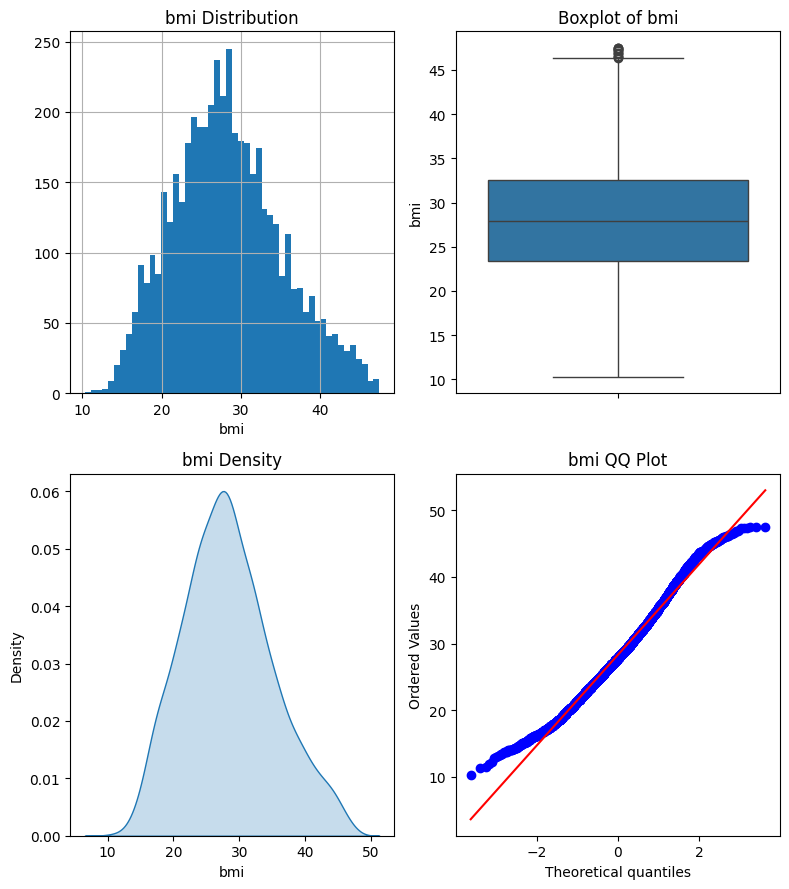

########################################


In [60]:
for col in numeric_features:
    num_summary(data_clean, col)

### Target Variable Analysis / Bivariate Analyses

Before jumping into modeling it's worth understanding how numerical features differ across stroke vs no-stroke cases. We can also see how severe the class imbalance is.

In [61]:
def target_summary_with_num(dataframe, target, numerical_col):
    summary = dataframe.groupby(target).agg({numerical_col: "mean"})
    print(summary, end="\n\n")

for col in numeric_features:
    target_summary_with_num(data_clean, "stroke", col)

              age
stroke           
0       41.702052
1       67.898551

        avg_glucose_level
stroke                   
0              103.666883
1              133.661981

              bmi
stroke           
0       28.227293
1       30.256039



Stroke patients are on average considerably older (~68 vs ~42) and have higher avg glucose levels (~133 vs ~105). BMI shows a smaller but still noticeable difference.

In [62]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

The dataset is heavily imbalanced. Only about 5% of records are positive stroke cases. This will be an important challenge for any classifier we train since a naive model can achieve ~95% accuracy by simply predicting no stroke for every patient.

In [63]:
def plot_stacked_barchart(data, title=None):
    pct = ((data.T / data.sum(axis=1)) * 100).T
    r = list(range(len(data)))
    bottom = [0] * len(data)
    
    for i, col in enumerate(pct.columns):
        bars = plt.bar(
            r, pct[col], bottom=bottom, color=('teal' if i==0 else 'crimson'),
            edgecolor='white', label=col
        )
        # annotate bars with actual counts and percentages
        for bar, raw in zip(bars, data[col]):
            height = bar.get_height()
            plt.text(
                x = bar.get_x() + bar.get_width() / 2,
                y = bar.get_y() + height / 2,
                s = f'{raw} ({round(height, 1)}%)',
                ha='center', va='center',
                color='black', fontsize=7
            )
        bottom = [b + p for b, p in zip(bottom, pct[col])]
    
    plt.title(title)
    plt.xticks(r, data.index, rotation=45)
    plt.ylabel('Portion %')
    plt.legend(loc='lower right', fontsize=8)

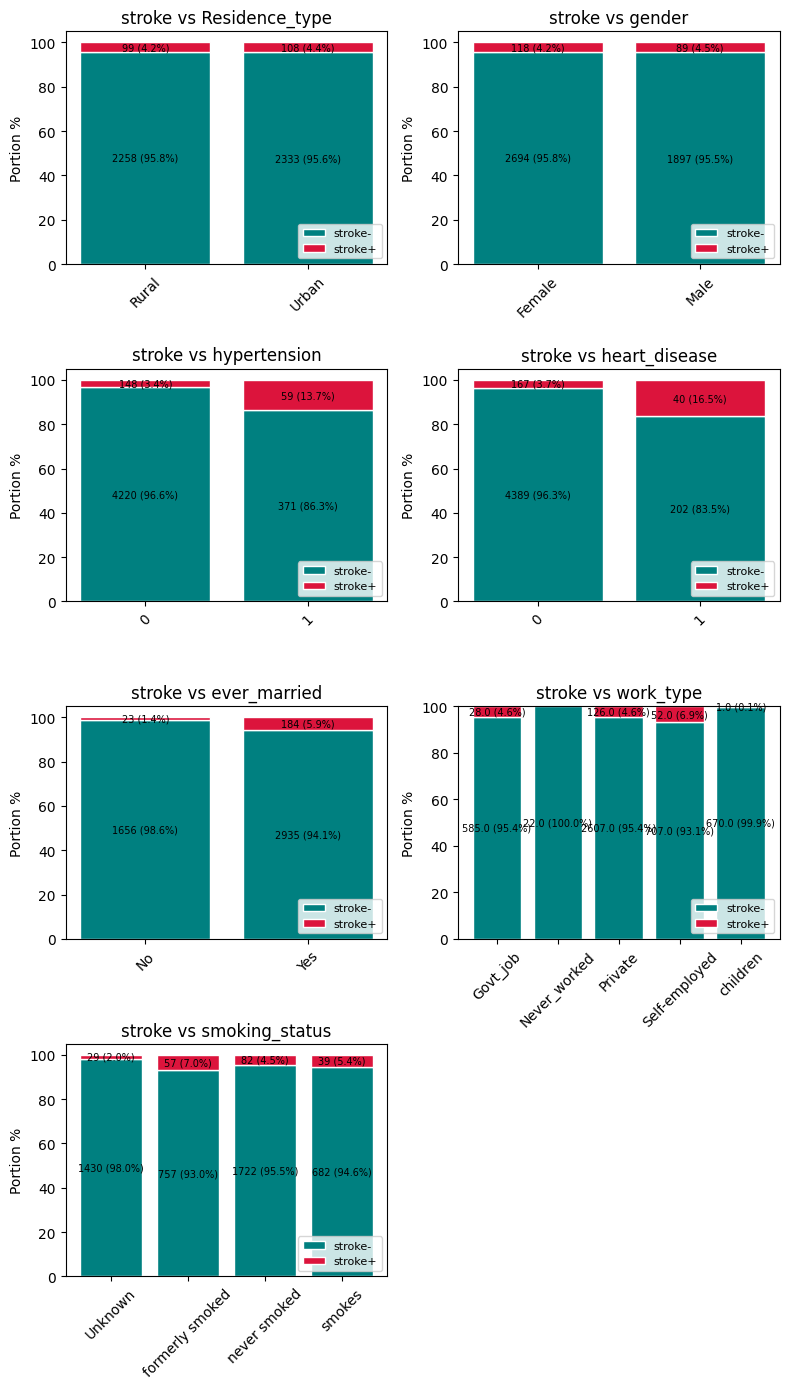

In [64]:
fig = plt.figure(figsize=(8, 14))

cat_comparisons = [(col, f'stroke vs {col}') for col in categorical_features]

for i, (feat, title) in enumerate(cat_comparisons, 1):
    plt.subplot(4, 2, i)
    temp_data = data_clean[[feat, 'stroke']].groupby([feat, 'stroke']).size().unstack('stroke')
    temp_data.columns = ['stroke-', 'stroke+']
    plot_stacked_barchart(temp_data, title=title)

plt.tight_layout()
plt.show()

Among categorical features, gender and residence_type don't show much of a difference for stroke positive to negative ratios; on the other hand, ever_married, hypertension and especially history of heart disease show visible disparity between proportion of stroke positive and negative...\
For multi-category features, self-employed in work_type shows higher proportion of stroke positive cases whereas Never-worked and children show lowest proporitons.\
And surprisingly in the smoking_status variable, the formerly smoked individuals are more prone to futrue stroke. Also note that "Unknown" smoking status is not close in proportion to any of the three other groups which is a problem and may introduce bias.

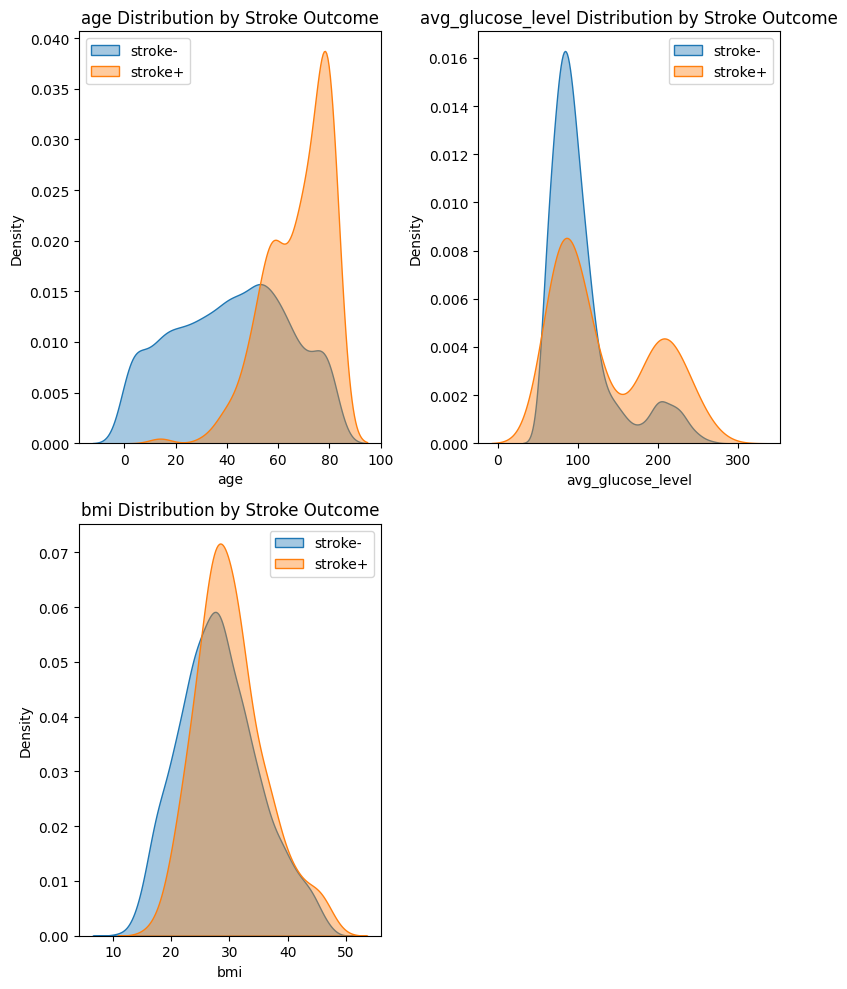

In [65]:
fig = plt.figure(figsize=(8, 10))
for i, feat in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(data_clean[data_clean['stroke'] == 0][feat], label='stroke-', fill=True, alpha=0.4)
    sns.kdeplot(data_clean[data_clean['stroke'] == 1][feat], label='stroke+', fill=True, alpha=0.4)
    plt.title(f'{feat} Distribution by Stroke Outcome')
    plt.xlabel(feat)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
plt.show()

As we can see there are clear separation and differences among the distributions among the numeric_features of stroke+ and stroke- cases.

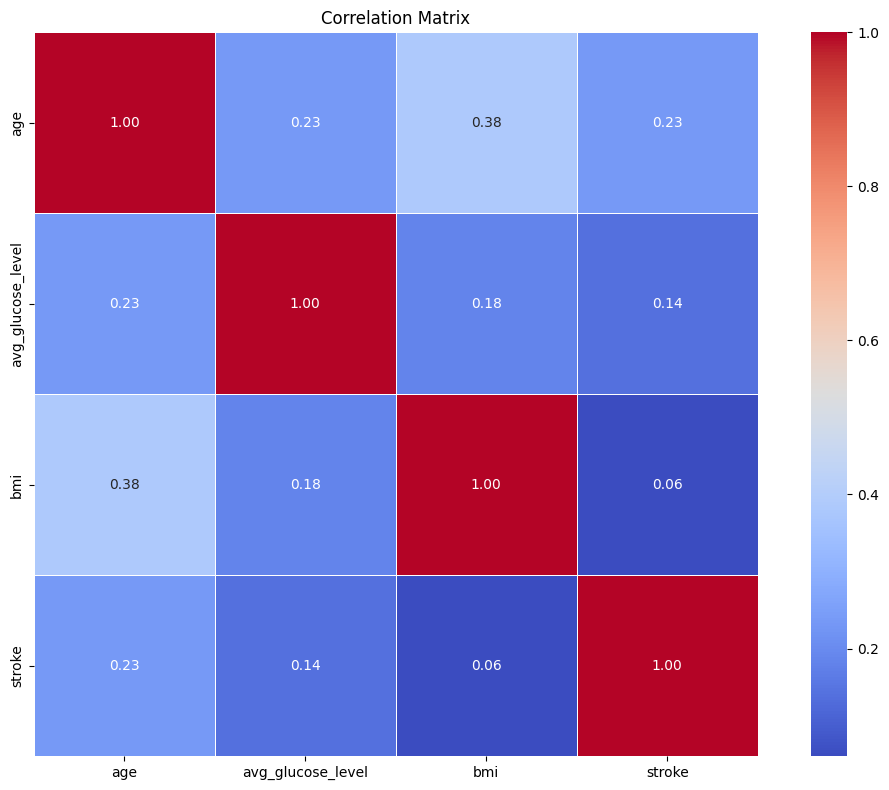

In [66]:
corr = data_clean[numeric_features + ['stroke']].corr()

plt.figure(figsize=(11, 8))
# mask = np.triu(np.ones_like(corr))
sns.heatmap(
    # corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm', linewidths=0.5, square=True
    corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Statistical Analyses

In [67]:
data_clean[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,4798.0,42.832247,22.724885,0.08,24.250,44.00,61.0000,82.00
avg_glucose_level,4798.0,104.960961,44.040560,55.12,77.040,91.65,113.2325,271.74
bmi,4798.0,28.314819,6.841431,10.30,23.425,27.90,32.6000,47.50


In [68]:
import scipy.stats as stats

stat, p = stats.shapiro(data_clean['age'])
print(f"Shapiro-Wilk statistic: {round(stat, 4)}")
print(f"p-value: {p:.4e}")

# H0: age is normally distributed
# H1: age is not normally distributed
if p < 0.05:
    print("p<0.05 (reject H0)")
else:
    print("p>0.05 (fail to reject H0)")

Shapiro-Wilk statistic: 0.9668
p-value: 7.0830e-32
p<0.05 (reject H0)


The Shapiro-Wilk test confirms what the Q-Q plot hints at: age deviates from a normal distribution

In [69]:
from scipy.stats import chi2_contingency, mannwhitneyu

# 1. Chi-Square Test for Categorical Features
chi2_results = []
for col in categorical_features:
    contingency_table = pd.crosstab(data_clean[col], data_clean['stroke'])
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({
        'Feature': col,
        'Test': 'Chi-Square',
        'p-value': p_val,
        'Significant (a=0.05)': p_val < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)

# 2. Mann-Whitney U Test for Numeric Features
mwu_results = []
for col in numeric_features:
    group0 = data_clean[data_clean['stroke'] == 0][col]
    group1 = data_clean[data_clean['stroke'] == 1][col]
    stat, p_val = mannwhitneyu(group0, group1, alternative='two-sided')
    mwu_results.append({
        'Feature': col,
        'Test': 'Mann-Whitney U',
        'p-value': p_val,
        'Significant (a=0.05)': p_val < 0.05
    })

mwu_df = pd.DataFrame(mwu_results)

# Combine, and sort by p-value to see strongest features first, and display
stat_results_df = pd.concat([chi2_df, mwu_df], ignore_index=True)
stat_results_df = stat_results_df.sort_values(by='p-value').reset_index(drop=True)
stat_results_df

,Feature,Test,p-value,Significant (a=0.05)
0,age,Mann-Whitney U,1.157949e-60,True
1,hypertension,Chi-Square,2.859414e-23,True
2,heart_disease,Chi-Square,3.912584e-21,True
3,ever_married,Chi-Square,3.088435e-13,True
4,avg_glucose_level,Mann-Whitney U,1.887515e-09,True
5,work_type,Chi-Square,1.925173e-08,True
6,smoking_status,Chi-Square,8.633761e-08,True
7,bmi,Mann-Whitney U,1.505041e-05,True
8,gender,Chi-Square,6.843462e-01,False
9,Residence_type,Chi-Square,7.558149e-01,False


Gender and Residence_type don't show statistically significant association with stroke outcome which is completely congruent with the chart results. This is not particularly compatible with the clinical insight that stroke is more common and deadlier in women than men (lifetime risk of 1/5 and 1/6 respectively). Also it is not compatible with the distribution among Rural/Urban residence areas (the rate is typically higher in rural areas, since rural populations often experience higher rates of stroke risk factors, such as hypertension, diabetes, and heart disease, along with reduced access to rapid, specialized stroke care.) 

## Baseline Model

Before doing any feature engineering or proper preprocessing, let's train a quick Random Forest to get a baseline sense of model performance. This will also help identify whether the class imbalance is actually problematic in practice.

In [70]:
dfd = pd.get_dummies(data_clean, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'], drop_first=True)

bool_cols = dfd.select_dtypes(include='bool').columns
dfd[bool_cols] = dfd[bool_cols].astype(int)

In [71]:
categorical_features

['Residence_type',
 'gender',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'smoking_status']

In [72]:
dfd.sample(3)

,hypertension,heart_disease,age,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
4228,0,0,68.0,76.09,26.0,0,1,1,0,0,1,0,0,0,0,1
1454,0,0,62.0,115.13,30.0,0,1,1,0,1,0,0,0,0,0,1
2679,0,0,15.0,190.13,20.7,0,1,0,0,1,0,0,1,0,1,0


In [73]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [74]:
y_base = dfd["stroke"]
X_base = dfd.drop("stroke", axis=1)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.25, random_state=42)

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_b, y_train_b)

RandomForestClassifier(random_state=42)

In [82]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

In [78]:
y_pred_base = rf_base.predict(X_test_b)

print("Train score:", round(rf_base.score(X_train_b, y_train_b), 4))
print("Test accuracy:", round(accuracy_score(y_test_b, y_pred_base), 4))

Train score: 1.0
Test accuracy: 0.9475


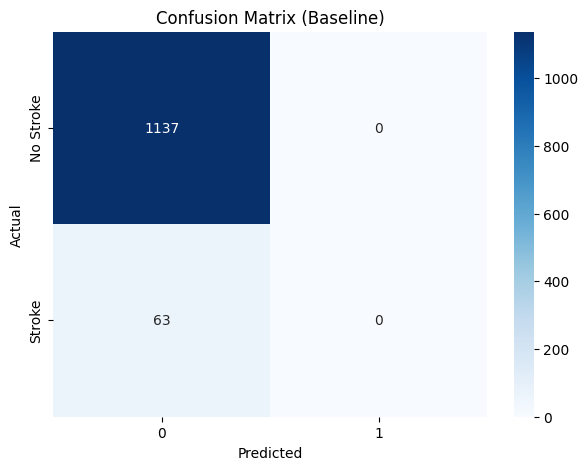

In [84]:
cm = confusion_matrix(y_test_b, y_pred_base)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", yticklabels=["No Stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Baseline)")
plt.show()

As expected the model gets nearly perfect training accuracy (essentially overfit) but fails completely on the minority class. Recall for stroke cases is 0 which means the model is just predicting no stroke for all the cases. Overall test accuracy looks decent at ~95% but that's just a reflection of the class imbalance and not actual predictive power.

This confirms we need to seriously address the imbalance and do proper feature engineering before building a real model.

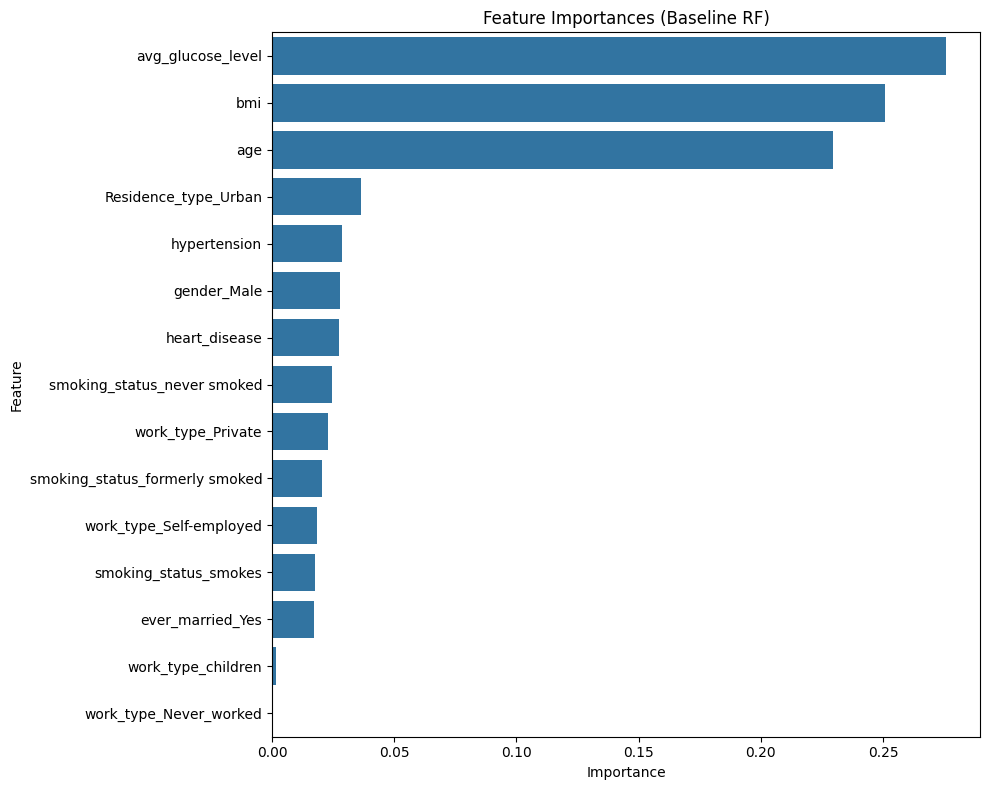

In [85]:
# feature importance from the baseline model, just to see what signals exist
feat_imp = pd.DataFrame({
    "Feature": X_base.columns,
    "Importance": rf_base.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importances (Baseline RF)")
plt.tight_layout()
plt.show()

In [86]:
data_clean.to_csv(os.path.join('..', 'data', 'data_clean.csv'))